In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
class Value:
  
  #Constructor - called when we create a new Value object

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    
    '''
    lambda is an anonymous function that is used to create a function object
    it is used when we need a simple function to be used as an argument to a higher-order function
    in this case, it is used to create a function object that is used as the default value for the _backward attribute
    '''
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data}, grad={self.grad}, op={self._op}, label={self.label})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out

In [47]:
print(x1)
print(x2)
print(w1)
print(w2)
print(x1w1)
print(x2w2)
print(x1w1x2w2)
print(n)
print(o)


Value(data=2.0, grad=0.0, op=, label=x1)
Value(data=0.0, grad=0.0, op=, label=x2)
Value(data=-3.0, grad=0.0, op=, label=w1)
Value(data=1.0, grad=0.0, op=, label=w2)
Value(data=-6.0, grad=0.0, op=*, label=x1*w1)
Value(data=0.0, grad=0.0, op=*, label=x2*w2)
Value(data=-6.0, grad=0.0, op=+, label=x1*w1 + x2*w2)
Value(data=0.8813735870195432, grad=0.4999999999999999, op=+, label=n)
Value(data=0.7071067811865476, grad=1.0, op=tanh, label=o)


In [51]:
print(n._op)

+


In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [75]:
o.grad = 1.0

In [76]:
#grad update is done on n Value object
#def _backward():
#    self.grad += (1 - t**2) * out.grad
# //out ---> o , o.grad = 1.0  , 
# self.grad ---> n  --- > 1- 0.7071067811865476**2 = 0.49

o._backward()

In [77]:
#n is a + operation on x1w1x2w2 and b Value object 
# // out ---> n , n.grad = 0.49
#def _backward():
#      self.grad += 1.0 * out.grad  //self ---> x1w1x2w2 = 0.49
#      other.grad += 1.0 * out.grad //other ---> b = 0.49
#n = x1w1x2w2 + b; 
n._backward()

In [78]:
#x1w1x2w2 is a + operation on x1w1 and x2w2 Value objects
# out ---> x1w1x2w2 , x1w1x2w2.grad = 0.49
#def _backward():
#      self.grad += 1.0 * out.grad  //self ---> x1w1 = 0.49
#      other.grad += 1.0 * out.grad //other ---> x2w2 = 0.49
#x1w1x2w2 = x1w1 + x2w2; 
x1w1x2w2._backward()

In [79]:
#x1w1 is a * operation on x1 and w1 Value objects
# out ---> x1w1 , x1w1.grad = 0.49
#def _backward():
#      self.grad += other.data * out.grad //self ---> x1 , 0.49 * -3 = -1.47
#      other.grad += self.data * out.grad //other ---> w1 , 2 * 0.49 = 0.98
#x1w1 = x1*w1; 
x1w1._backward()



In [80]:
#x2w2 is a * operation on x2 and w2 Value objects
# out ---> x2w2 , x2w2.grad = 0.49
#def _backward():
#      self.grad += other.data * out.grad //self ---> x2 , 0.49 * 1 = 0.49
#      other.grad += self.data * out.grad //other ---> w2 , 0 * 0.49 = 0
#x2w2 = x2*w2; 
x2w2._backward()

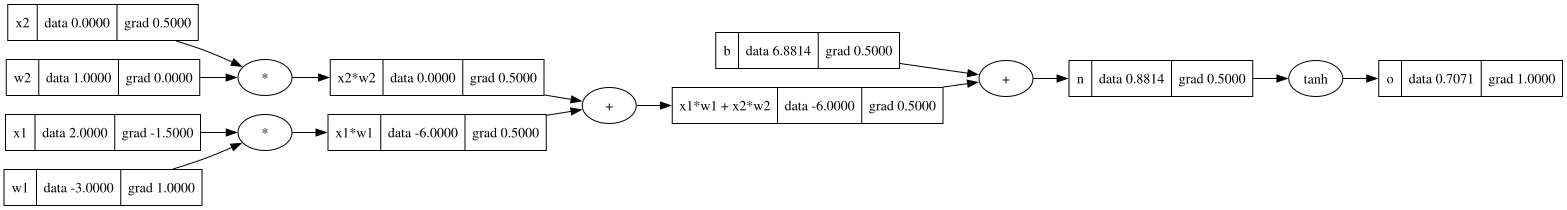

In [81]:
draw_dot(o)

In [73]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' 
o = n.tanh(); o.label = 'o' # Final Output - Creates a new Value object by using tanh function on n Value object

In [24]:
n.data

0.8813735870195432

In [ ]:
 def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()